# ABC Company Employee Analysis

## End Project

**Objective:**
To preprocess the employee dataset, perform exploratory data analysis, visualize key insights, and identify trends in employee distribution, age, positions, salaries, and correlations.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


##Preprocessing:
● Correct the data in the "height" column by replacing it with random
numbers between 150 and 180. Ensure data consistency and integrity
before proceeding with analysis. (1 mark)

In [12]:
df = pd.read_csv("ABC Company.csv")

In [14]:
 df.head(5)
 df.shape
 df.columns
 df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 458 entries, 0 to 457
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      458 non-null    object 
 1   Team      458 non-null    object 
 2   Number    458 non-null    int64  
 3   Position  458 non-null    object 
 4   Age       458 non-null    int64  
 5   Height    458 non-null    object 
 6   Weight    458 non-null    int64  
 7   College   374 non-null    object 
 8   Salary    447 non-null    float64
dtypes: float64(1), int64(3), object(5)
memory usage: 32.3+ KB


In [20]:
df["Height"] = np.random.randint(150,181,458)

In [21]:
df.head(5)

,Name,Team,Number,Position,Age,Height,Weight,College,Salary
0,Avery Bradley,Boston Celtics,0,PG,25,170,180,Texas,7730337.0
1,Jae Crowder,Boston Celtics,99,SF,25,173,235,Marquette,6796117.0
2,John Holland,Boston Celtics,30,SG,27,178,205,Boston University,NaN
3,R.J. Hunter,Boston Celtics,28,SG,22,179,185,Georgia State,1148640.0
4,Jonas Jerebko,Boston Celtics,8,PF,29,162,231,NaN,5000000.0


In [22]:
df["Height"].head()
df["Height"].describe()

count    458.000000
mean     165.043668
std        8.861335
min      150.000000
25%      158.000000
50%      165.000000
75%      172.000000
max      180.000000
Name: Height, dtype: float64

##Analysis Tasks:
● Determine the distribution of employees across each team and calculate
the percentage split relative to the total number of employees. (2 marks)

In [27]:
team_distribution = df["Team"].value_counts()
print(team_distribution)

team_percentage = (team_distribution / len(df)) * 100
print(team_percentage)

Team
New Orleans Pelicans      19
Memphis Grizzlies         18
Utah Jazz                 16
Milwaukee Bucks           16
New York Knicks           16
Boston Celtics            15
Los Angeles Clippers      15
Los Angeles Lakers        15
Phoenix Suns              15
Sacramento Kings          15
Brooklyn Nets             15
Philadelphia 76ers        15
Toronto Raptors           15
Golden State Warriors     15
Indiana Pacers            15
Detroit Pistons           15
Cleveland Cavaliers       15
Chicago Bulls             15
Houston Rockets           15
San Antonio Spurs         15
Atlanta Hawks             15
Dallas Mavericks          15
Charlotte Hornets         15
Miami Heat                15
Denver Nuggets            15
Washington Wizards        15
Portland Trail Blazers    15
Oklahoma City Thunder     15
Orlando Magic             14
Minnesota Timberwolves    14
Name: count, dtype: int64
Team
New Orleans Pelicans      4.148472
Memphis Grizzlies         3.930131
Utah Jazz               

##● Segregate employees based on their positions within the company. (2
marks)

In [29]:
employee_position = df["Position"].value_counts()
print(employee_position)

Position
SG    102
PF    100
PG     92
SF     85
C      79
Name: count, dtype: int64


● Identify the predominant age group among employees. (2 marks)

In [30]:
print(df["Age"].min())
print(df["Age"].max())

19
40


In [44]:
bins = [18, 25, 35, 45, 55]
labels = ["18-25", "26-35", "36-45", "46-55"]

df["Age_Group"] = pd.cut(df["Age"], bins=bins, labels=labels)

age_group_distribution = df["Age_Group"].value_counts()

print(age_group_distribution)

Age_Group
26-35    235
18-25    200
36-45     23
46-55      0
Name: count, dtype: int64


##● Discover which team and position have the highest salary expenditure. (2 marks)

In [32]:
# Team salary expenditure
team_salary = df.groupby("Team")["Salary"].sum()
print("Team Salary Expenditure")
print(team_salary)

print("Highest Salary Expenditure Team:", team_salary.idxmax())


# Position salary expenditure
position_salary = df.groupby("Position")["Salary"].sum()
print("Position Salary Expenditure")
print(position_salary)

print("Highest Salary Expenditure Position:", position_salary.idxmax())

Team Salary Expenditure
Team
Atlanta Hawks              72902950.0
Boston Celtics             58541068.0
Brooklyn Nets              52528475.0
Charlotte Hornets          78340920.0
Chicago Bulls              86783378.0
Cleveland Cavaliers       106988689.0
Dallas Mavericks           71198732.0
Denver Nuggets             60121930.0
Detroit Pistons            67168263.0
Golden State Warriors      88868997.0
Houston Rockets            75283021.0
Indiana Pacers             66751826.0
Los Angeles Clippers       94854640.0
Los Angeles Lakers         71770431.0
Memphis Grizzlies          76550880.0
Miami Heat                 82515673.0
Milwaukee Bucks            69603517.0
Minnesota Timberwolves     59709697.0
New Orleans Pelicans       82750774.0
New York Knicks            73303898.0
Oklahoma City Thunder      93765298.0
Orlando Magic              60161470.0
Philadelphia 76ers         30992894.0
Phoenix Suns               63445135.0
Portland Trail Blazers     48301818.0
Sacramento Kings     

##● Investigate if there's any correlation between age and salary, and
represent it visually. (2 marks)

In [33]:
correlation = df["Age"].corr(df["Salary"])
print(correlation)

0.2140094122657097


##Graphical Representation:
● For each of the five analysis tasks above, create appropriate visualizations
to present your findings effectively. (5x2 = 10 marks)

 ##Graph 1: Distribution of Employees Across Teams

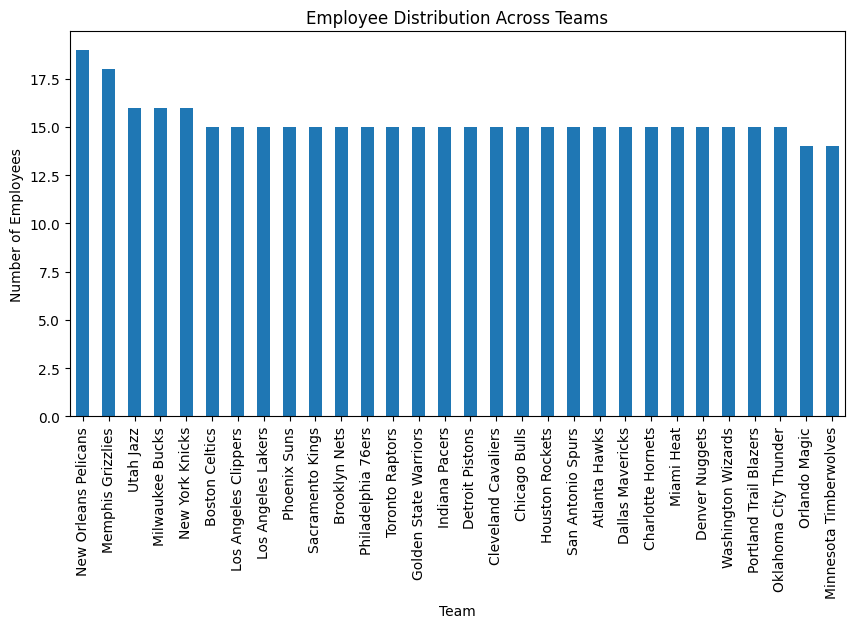

In [34]:
plt.figure(figsize=(10,5))
team_distribution.plot(kind="bar")

plt.title("Employee Distribution Across Teams")
plt.xlabel("Team")
plt.ylabel("Number of Employees")
plt.show()

##Graph 2: Distribution of Employees by Position

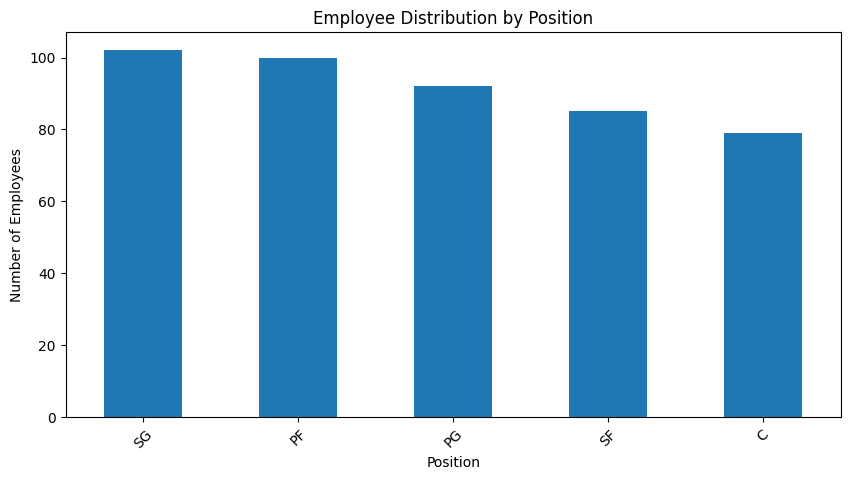

In [35]:
plt.figure(figsize=(10,5))
employee_position.plot(kind="bar")

plt.title("Employee Distribution by Position")
plt.xlabel("Position")
plt.ylabel("Number of Employees")
plt.xticks(rotation=45)
plt.show()

##Graph 3: Predominant Age Group

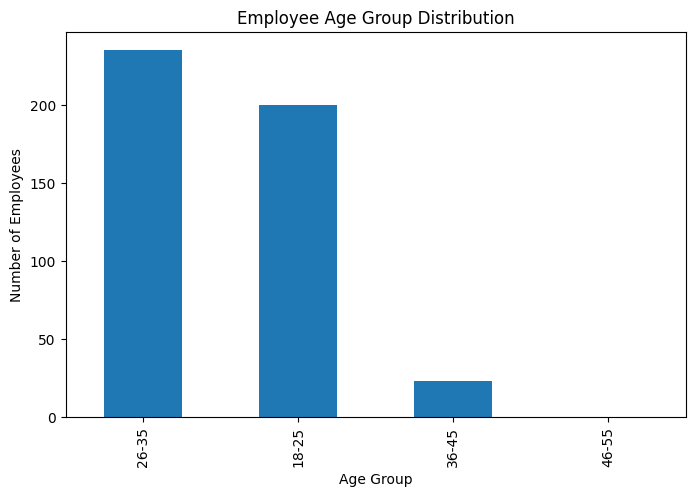

In [45]:
plt.figure(figsize=(8,5))

age_group_distribution.plot(kind="bar")

plt.title("Employee Age Group Distribution")
plt.xlabel("Age Group")
plt.ylabel("Number of Employees")

plt.show()

##Graph 4: Team Salary Expenditure

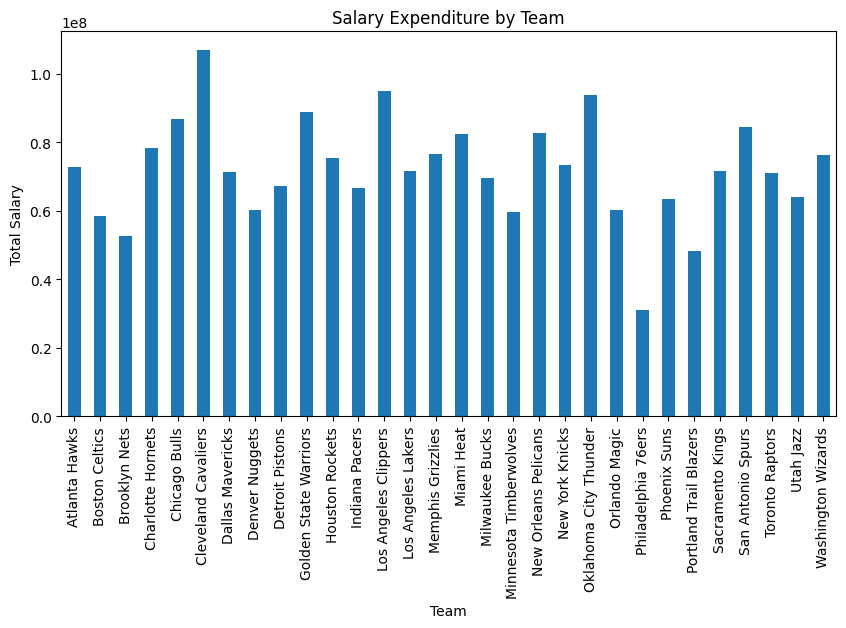

In [37]:
plt.figure(figsize=(10,5))
team_salary.plot(kind="bar")

plt.title("Salary Expenditure by Team")
plt.xlabel("Team")
plt.ylabel("Total Salary")
plt.show()

##Graph 5: Age vs Salary (Correlation)

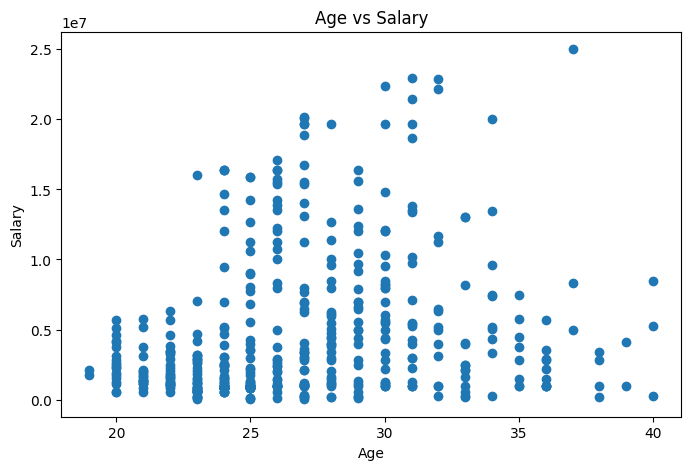

In [38]:
plt.figure(figsize=(8,5))
plt.scatter(df["Age"], df["Salary"])

plt.title("Age vs Salary")
plt.xlabel("Age")
plt.ylabel("Salary")
plt.show()

Data Story / Insights (Copy this into a Markdown cell)
Data Story / Insights
The employees are distributed across multiple teams, with some teams having significantly more employees than others.
The company has employees working in various positions. Some positions have a higher number of employees compared to others.
The majority of employees belong to a specific age group, indicating that this age range forms the largest part of the workforce.
Salary expenditure differs across teams and positions. Some teams and positions contribute more to the overall salary expenditure of the company.
The correlation between age and salary is (mention your correlation result here).
* If the value is positive, salary tends to increase with age.
* If the value is negative, salary tends to decrease with age.
* If the value is close to 0, there is little or no relationship between age and salary.